# Sudoku Solver
**Machine Learning Spring 2025/2026**



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time
import warnings
import copy
warnings.filterwarnings('ignore')

## 1. Loading the data

In [5]:
def load_and_subsample(path, n_samples=50000, seed=42):
    df = pd.read_csv(path)
    df = df.sample(n_samples, random_state=seed).reset_index(drop=True)
    return df['puzzle'].values, df['solution'].values

puzzles, solutions = load_and_subsample('data/sudoku.csv', n_samples=50000)
print(f'Loaded {len(puzzles):,} puzzles')
print('Example puzzle  :', puzzles[0])
print('Example solution:', solutions[0])

Loaded 50,000 puzzles
Example puzzle  : 910700000065800000078004695020401007081000209006000400003670908000108030040509176
Example solution: 914756823265893714378214695529481367481367259736925481153672948697148532842539176


Text(0.5, 1.0, 'Distribution of Empty Cells in Sudoku Puzzles')

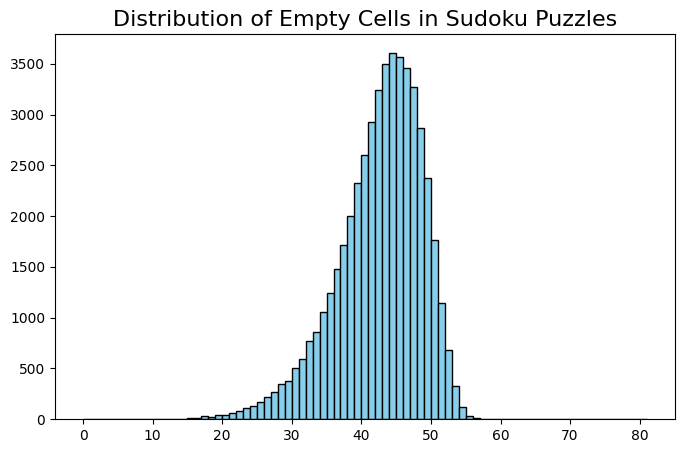

In [26]:
empty_counts = np.array([p.count('0') for p in puzzles])
plt.figure(figsize=(8,5))
plt.hist(empty_counts, bins=np.arange(0, 82, 1), color='skyblue', edgecolor='black')
plt.title('Distribution of Empty Cells in Sudoku Puzzles', fontsize=16)

In [27]:
# Choose puzzles with the most empty cells
N_HARD = 200
idx_sorted = np.argsort(empty_counts)[::-1]  # descending
hard_idx = idx_sorted[:N_HARD]

hard_puzzles = [puzzles[i] for i in hard_idx]
hard_solutions = [solutions[i] for i in hard_idx]

print("Average emptiness of hard puzzles:", np.mean([p.count('0') for p in hard_puzzles]))

Average emptiness of hard puzzles: 54.105


## 2. Data preprocessing

In [6]:
def str_to_grid(s):
    return np.array([int(c) for c in s]).reshape(9, 9)

def one_hot_encode_grid(grid):
    one_hot = np.zeros((9, 9, 9), dtype=np.float32)
    for i in range(9):
        for j in range(9):
            d = grid[i, j]
            if d != 0:
                one_hot[i, j, d-1] = 1.0
    return one_hot

def split_puzzles(puzzles, solutions, test_size=0.1, val_size=0.1, seed=42):
    p_train, p_temp, s_train, s_temp = train_test_split(
        puzzles, solutions, test_size=test_size+val_size, random_state=seed)
    relative_val = val_size / (test_size + val_size)
    p_val, p_test, s_val, s_test = train_test_split(
        p_temp, s_temp, test_size=1-relative_val, random_state=seed)
    return (p_train, s_train), (p_val, s_val), (p_test, s_test)

(train_p, train_s), (val_p, val_s), (test_p, test_s) = split_puzzles(puzzles, solutions)
print(f'Train: {len(train_p):,} | Val: {len(val_p):,} | Test: {len(test_p):,}')

Train: 40,000 | Val: 5,000 | Test: 5,000


In [7]:
# Build flat X (N, 729) and Y (N, 81) for RF/XGBoost
# Build 2D X (N, 9, 9, 9) for CNN

def build_flat_dataset(puzzles, solutions):
    X = np.array([one_hot_encode_grid(str_to_grid(p)).flatten() for p in puzzles])
    Y = np.array([[int(c)-1 for c in s] for s in solutions])
    return X, Y

def build_2d_dataset(puzzles, solutions):
    X = np.array([one_hot_encode_grid(str_to_grid(p)) for p in puzzles])
    Y = np.array([[int(c)-1 for c in s] for s in solutions]).reshape(-1, 9, 9)
    return X, Y

print('Building datasets...')
X_train, Y_train = build_flat_dataset(train_p, train_s)
X_val,   Y_val   = build_flat_dataset(val_p,   val_s)
X_test,  Y_test  = build_flat_dataset(test_p,  test_s)

X_train_2d, Y_train_2d = build_2d_dataset(train_p, train_s)
X_test_2d,  Y_test_2d  = build_2d_dataset(test_p,  test_s)
X_val_2d,   Y_val_2d   = build_2d_dataset(val_p,   val_s)

print(f'X_train shape: {X_train.shape}  (flat)')
print(f'X_train_2d shape: {X_train_2d.shape}  (2D for CNN)')

Building datasets...
X_train shape: (40000, 729)  (flat)
X_train_2d shape: (40000, 9, 9, 9)  (2D for CNN)


## 3. Evaluation metrics

In [8]:
def evaluate(Y_true, Y_pred, label='Model'):
    Y_true, Y_pred = np.array(Y_true), np.array(Y_pred)
    cell_acc   = (Y_true == Y_pred).mean()
    puzzle_acc = (Y_true == Y_pred).all(axis=1).mean()
    print(f'[{label}]')
    print(f'  Per-cell accuracy  : {cell_acc*100:.2f}%')
    print(f'  Per-puzzle accuracy: {puzzle_acc*100:.2f}%')
    return {'label': label, 'cell_acc': cell_acc, 'puzzle_acc': puzzle_acc}

results = []

## 4. STRATEGIES

### 4. 1 STRATEGY - FULL GRID PREDICTION

In this approach, the model sees the full puzzle (one-hot encoded) and predicts all 81 cells at once, independently.

#### 4.1.1 Models

##### 4.1.1.1 Random Forest

In [9]:
#RF using validation set for hyperparameter tuning

# Hyperparameter candidates
rf_params = [
    {"n_estimators": 20, "max_depth": 10},
    {"n_estimators": 30, "max_depth": 12},
    {"n_estimators": 50, "max_depth": 15},
]

best_score = -1
best_params = None

print("Tuning RF...")
for params in rf_params:
    print("Testing:", params)
    models = []
    for cell in range(81):
        clf = RandomForestClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            n_jobs=-1,
            random_state=42
        )
        clf.fit(X_train, Y_train[:, cell])
        models.append(clf)

    preds = np.column_stack([m.predict(X_val) for m in models])
    score = accuracy_score(Y_val.flatten(), preds.flatten())

    if score > best_score:
        best_score = score
        best_params = params

print("Best RF params:", best_params)

# Retrain on train+val
X_full = np.vstack([X_train, X_val])
Y_full = np.vstack([Y_train, Y_val])

rf_models = []
for cell in range(81):
    clf = RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_full, Y_full[:, cell])
    rf_models.append(clf)

# Test
rf_test_preds = np.column_stack([m.predict(X_test) for m in rf_models])
r = evaluate(Y_test, rf_test_preds, "Strategy 1 - RF final")
results.append(r)

Tuning RF...
Testing: {'n_estimators': 20, 'max_depth': 10}
Testing: {'n_estimators': 30, 'max_depth': 12}
Testing: {'n_estimators': 50, 'max_depth': 15}
Best RF params: {'n_estimators': 50, 'max_depth': 15}
[Strategy 1 - RF final]
  Per-cell accuracy  : 63.00%
  Per-puzzle accuracy: 0.00%


##### 4.1.1.2 XGBoost

In [10]:
# XGBoost using validation set for hyperparameter tuning
xgb_params = [
    {"max_depth": 3, "n_estimators": 30, "learning_rate": 0.1},
    {"max_depth": 4, "n_estimators": 50, "learning_rate": 0.1},
]

best_score = -1
best_params = None

print("Tuning XGBoost...")
for params in xgb_params:
    print("Testing:", params)
    models = []
    for cell in range(81):
        clf = XGBClassifier(
            max_depth=params["max_depth"],
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="mlogloss",
            n_jobs=-1,
            random_state=42,
            verbosity=0
        )
        clf.fit(X_train, Y_train[:, cell])
        models.append(clf)

    preds = np.column_stack([m.predict(X_val) for m in models])
    score = accuracy_score(Y_val.flatten(), preds.flatten())

    if score > best_score:
        best_score = score
        best_params = params

print("Best XGB params:", best_params)

# Retrain on train+val
xgb_models = []
for cell in range(81):
    clf = XGBClassifier(
        max_depth=best_params["max_depth"],
        n_estimators=best_params["n_estimators"],
        learning_rate=best_params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
    clf.fit(X_full, Y_full[:, cell])
    xgb_models.append(clf)

# Test
xgb_test_preds = np.column_stack([m.predict(X_test) for m in xgb_models])
r = evaluate(Y_test, xgb_test_preds, "Strategy 1 - XGB final")
results.append(r)

Tuning XGBoost...
Testing: {'max_depth': 3, 'n_estimators': 30, 'learning_rate': 0.1}
Testing: {'max_depth': 4, 'n_estimators': 50, 'learning_rate': 0.1}
Best XGB params: {'max_depth': 4, 'n_estimators': 50, 'learning_rate': 0.1}
[Strategy 1 - XGB final]
  Per-cell accuracy  : 73.04%
  Per-puzzle accuracy: 0.02%


##### 4.1.1.3 Neural Network (PyTorch CNN)

In [11]:
# CNN with validation set
device = "cuda" if torch.cuda.is_available() else "cpu"

class SudokuCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(9, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 9, 1)
        )
    def forward(self, x):
        x = x.permute(0, 3, 1, 2)
        return self.net(x)

train_ds = TensorDataset(
    torch.tensor(X_train_2d, dtype=torch.float32),
    torch.tensor(Y_train_2d, dtype=torch.long)
)
val_ds = TensorDataset(
    torch.tensor(X_val_2d, dtype=torch.float32),
    torch.tensor(Y_val_2d, dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)

cnn = SudokuCNN().to(device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val = 0
best_state = None

print("Training CNN...")
for epoch in range(30):
    cnn.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = cnn(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    # Validation
    cnn.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = cnn(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_acc = correct / total
    print(f"Epoch {epoch+1}: val acc = {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(cnn.state_dict())

# Load best model
cnn.load_state_dict(best_state)

# Test
cnn.eval()
with torch.no_grad():
    out = cnn(torch.tensor(X_test_2d, dtype=torch.float32).to(device))
    cnn_test_preds = out.argmax(dim=1).cpu().numpy().reshape(-1, 81)

r = evaluate(Y_test, cnn_test_preds, "Strategy 1 - CNN (PyTorch)")
results.append(r)


Training CNN...
Epoch 1: val acc = 0.5831
Epoch 2: val acc = 0.5862
Epoch 3: val acc = 0.5875
Epoch 4: val acc = 0.5878
Epoch 5: val acc = 0.5893
Epoch 6: val acc = 0.5898
Epoch 7: val acc = 0.5898
Epoch 8: val acc = 0.5902
Epoch 9: val acc = 0.5905
Epoch 10: val acc = 0.5906
Epoch 11: val acc = 0.5909
Epoch 12: val acc = 0.5905
Epoch 13: val acc = 0.5915
Epoch 14: val acc = 0.5911
Epoch 15: val acc = 0.5910
Epoch 16: val acc = 0.5905
Epoch 17: val acc = 0.5911
Epoch 18: val acc = 0.5907
Epoch 19: val acc = 0.5906
Epoch 20: val acc = 0.5913
Epoch 21: val acc = 0.5906
Epoch 22: val acc = 0.5911
Epoch 23: val acc = 0.5917
Epoch 24: val acc = 0.5914
Epoch 25: val acc = 0.5913
Epoch 26: val acc = 0.5911
Epoch 27: val acc = 0.5915
Epoch 28: val acc = 0.5913
Epoch 29: val acc = 0.5919
Epoch 30: val acc = 0.5914
[Strategy 1 - CNN (PyTorch)]
  Per-cell accuracy  : 59.08%
  Per-puzzle accuracy: 0.00%


##### 4.1.1.4 MLP

In [12]:

device = "cuda" if torch.cuda.is_available() else "cpu"

class SudokuMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(729, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(),
            nn.Linear(1024, 729)
        )
    def forward(self, x):
        b = x.size(0)
        x = x.reshape(b, -1)
        out = self.net(x)
        return out.reshape(b, 9, 9, 9)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(Y_train.reshape(-1, 9, 9), dtype=torch.long)
)
val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(Y_val.reshape(-1, 9, 9), dtype=torch.long)
)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512)

mlp = SudokuMLP().to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val = 0
best_state = None

print("Training MLP...")
for epoch in range(30):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = mlp(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

    # Validation
    mlp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = mlp(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_acc = correct / total
    print(f"Epoch {epoch+1}: val acc = {val_acc:.4f}")

    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(mlp.state_dict())

# Load best model
mlp.load_state_dict(best_state)

# Evaluate on test
mlp.eval()
with torch.no_grad():
    out = mlp(torch.tensor(X_test, dtype=torch.float32).to(device))
    mlp_test_preds = out.argmax(dim=1).cpu().numpy().reshape(-1, 81)

r = evaluate(Y_test, mlp_test_preds, "Strategy 1 - MLP (PyTorch)")
results.append(r)

Training MLP...
Epoch 1: val acc = 0.5190
Epoch 2: val acc = 0.5989
Epoch 3: val acc = 0.6187
Epoch 4: val acc = 0.6267
Epoch 5: val acc = 0.6323
Epoch 6: val acc = 0.6397
Epoch 7: val acc = 0.6430
Epoch 8: val acc = 0.6460
Epoch 9: val acc = 0.6498
Epoch 10: val acc = 0.6554
Epoch 11: val acc = 0.6605
Epoch 12: val acc = 0.6609
Epoch 13: val acc = 0.6643
Epoch 14: val acc = 0.6671
Epoch 15: val acc = 0.6723
Epoch 16: val acc = 0.6754
Epoch 17: val acc = 0.6769
Epoch 18: val acc = 0.6796
Epoch 19: val acc = 0.6810
Epoch 20: val acc = 0.6852
Epoch 21: val acc = 0.6876
Epoch 22: val acc = 0.6897
Epoch 23: val acc = 0.6922
Epoch 24: val acc = 0.6925
Epoch 25: val acc = 0.6951
Epoch 26: val acc = 0.6976
Epoch 27: val acc = 0.6991
Epoch 28: val acc = 0.7013
Epoch 29: val acc = 0.7045
Epoch 30: val acc = 0.7063
[Strategy 1 - MLP (PyTorch)]
  Per-cell accuracy  : 70.48%
  Per-puzzle accuracy: 0.00%


### 4.2 STRATEGY - Step-by-step next-cell prediction

In this approach we fill one empty cell at a time. At each step, the model picks the most confident empty cell and fills it. This is repeated until the puzzle is complete. This mimics how humans solve Sudoku — incrementally.

In [13]:
# Additional helper functions for encoding 

def encode_puzzle_flat(puzzle_str):
    grid = str_to_grid(puzzle_str)
    return one_hot_encode_grid(grid).flatten()   # shape (729,)

def encode_puzzle_2d(puzzle_str):
    grid = str_to_grid(puzzle_str)
    return one_hot_encode_grid(grid)             # shape (9,9,9)


In [14]:

device = "cuda" if torch.cuda.is_available() else "cpu"

def solve_step_by_step(puzzle_str, model, model_type="mlp", max_steps=81):
    """
    Step-by-step Sudoku solving using full-grid prediction.
    Fills the most confident empty cell at each iteration.
    """

    puzzle = list(puzzle_str)

    for step in range(max_steps):

        # Find empty cells
        empty_cells = [i for i, c in enumerate(puzzle) if c == '0']
        if not empty_cells:
            break  # solved

        # ----------------------------------------------------
        # MLP MODEL (flat input, output shape = (1, 9, 9, 9))
        # ----------------------------------------------------
        if model_type == "mlp":
            x = encode_puzzle_flat(''.join(puzzle)).reshape(1, -1)
            x = torch.tensor(x, dtype=torch.float32).to(device)

            with torch.no_grad():
                out = model(x)                     # (1, 9, 9, 9)
                probs = torch.softmax(out, dim=-1)[0].cpu().numpy()

            best_cell, best_conf, best_digit = -1, -1, -1
            for cell in empty_cells:
                r, c = cell // 9, cell % 9
                p = probs[r, c]                    # (9,)
                conf = p.max()
                if conf > best_conf:
                    best_conf = conf
                    best_cell = cell
                    best_digit = p.argmax() + 1

        # ----------------------------------------------------
        # CNN MODEL (2D input, output shape = (1, 9, 9, 9))
        # ----------------------------------------------------
        elif model_type == "cnn":
            x = encode_puzzle_2d(''.join(puzzle)).reshape(1, 9, 9, 9)
            x = torch.tensor(x, dtype=torch.float32).to(device)

            with torch.no_grad():
                out = model(x)                     # (1, 9, 9, 9)
                probs = torch.softmax(out, dim=1)[0].cpu().numpy()

            best_cell, best_conf, best_digit = -1, -1, -1
            for cell in empty_cells:
                r, c = cell // 9, cell % 9
                p = probs[:, r, c]                 # (9,)
                conf = p.max()
                if conf > best_conf:
                    best_conf = conf
                    best_cell = cell
                    best_digit = p.argmax() + 1

        # Fill the chosen cell
        puzzle[best_cell] = str(best_digit)

    return ''.join(puzzle)


In [15]:
# Number of puzzles to evaluate with Strategy 2
N_EVAL_S2 = 300   

# Take the first N puzzles from your test split
test_puzzles   = test_p[:N_EVAL_S2]
test_solutions = test_s[:N_EVAL_S2]

for model_type, model in [('mlp', mlp), ('cnn', cnn)]:
    print(f"\nRunning Strategy 2 — {model_type.upper()} (n={N_EVAL_S2})...")
    t0 = time.time()

    preds = []
    for p in test_puzzles:
        solved = solve_step_by_step(p, model=model, model_type=model_type)
        preds.append(solved)

    # Convert predictions and ground truth to integer arrays 0–8
    Y_pred_s2 = np.array([[int(c)-1 for c in pred] for pred in preds])
    Y_true_s2 = np.array([[int(c)-1 for c in sol]  for sol  in test_solutions])

    label = f"Strategy 2 — {model_type.upper()}"
    r = evaluate(Y_true_s2, Y_pred_s2, label)
    results.append(r)

    print(f"  Time: {time.time()-t0:.1f}s")



Running Strategy 2 — MLP (n=300)...
[Strategy 2 — MLP]
  Per-cell accuracy  : 54.17%
  Per-puzzle accuracy: 0.00%
  Time: 3.6s

Running Strategy 2 — CNN (n=300)...
[Strategy 2 — CNN]
  Per-cell accuracy  : 58.62%
  Per-puzzle accuracy: 0.00%
  Time: 5.1s


### 4.3 STRATEGY - ML guided backtracking

In [16]:
def is_valid(grid, row, col, digit):
    """
    Check if placing `digit` at (row, col) is valid.
    grid: 9x9 numpy array
    """
    # Row check
    if digit in grid[row]:
        return False
    # Column check
    if digit in grid[:, col]:
        return False
    # 3x3 box check
    box_r, box_c = (row // 3) * 3, (col // 3) * 3
    if digit in grid[box_r:box_r+3, box_c:box_c+3]:
        return False
    return True

In [17]:
def get_candidates_rf(grid, row, col, cell_idx):
    """Get digit ranking from RF for cell at (row, col)."""
    x = one_hot_encode_grid(grid).flatten().reshape(1, -1)
    proba = rf_models[cell_idx].predict_proba(x)[0]  # shape (9,)
    # predict_proba only returns seen classes — map back to full 9
    classes = rf_models[cell_idx].classes_
    full_proba = np.zeros(9)
    for i, c in enumerate(classes):
        full_proba[c] = proba[i]
    return np.argsort(full_proba)[::-1] + 1  # digits 1-9, most confident first

def get_candidates_xgb(grid, row, col, cell_idx):
    """Get digit ranking from XGBoost for cell at (row, col)."""
    x = one_hot_encode_grid(grid).flatten().reshape(1, -1)
    proba = xgb_models[cell_idx].predict_proba(x)[0]
    return np.argsort(proba)[::-1] + 1

def get_candidates_cnn(grid, row, col):
    """Get digit ranking from CNN for cell at (row, col)."""
    x = torch.tensor(one_hot_encode_grid(grid)).unsqueeze(0).to(device)
    with torch.no_grad():
        out = cnn(x)  # (1, 9, 9, 9)
    proba = torch.softmax(out[0, :, row, col], dim=0).cpu().numpy()
    return np.argsort(proba)[::-1] + 1

def get_candidates_mlp(grid, row, col):
    """Get digit ranking from MLP for cell at (row, col)."""
    x = one_hot_encode_grid(grid).flatten().reshape(1, -1)
    x = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        out = mlp(x)  # (1, 9, 9, 9)
        proba = torch.softmax(out[0, row, col], dim=0).cpu().numpy()

    return np.argsort(proba)[::-1] + 1 


def ml_guided_backtrack(puzzle_str, model='cnn', time_limit=10.0):
    """
    Solve puzzle using ML-guided backtracking.
    model: 'rf', 'xgb', 'cnn', or 'mlp'
    Returns solved grid string or None if timeout.
    """
    grid = str_to_grid(puzzle_str).copy()
    start = time.time()

    def backtrack():
        if time.time() - start > time_limit:
            return False

        # Find first empty cell
        empties = np.argwhere(grid == 0)
        if len(empties) == 0:
            return True  # Solved!

        row, col = empties[0]
        cell_idx = row * 9 + col

        # Get ML-ranked candidates
        if model == 'rf':
            candidates = get_candidates_rf(grid, row, col, cell_idx)
        elif model == 'xgb':
            candidates = get_candidates_xgb(grid, row, col, cell_idx)
        elif model == 'cnn':
            candidates = get_candidates_cnn(grid, row, col)
        elif model == 'mlp':
            candidates = get_candidates_mlp(grid, row, col)
        else:
            raise ValueError("Unknown model type")
        
        for digit in candidates:
            if is_valid(grid, row, col, digit):
                grid[row, col] = digit
                if backtrack():
                    return True
                grid[row, col] = 0  # undo

        return False

    solved = backtrack()
    if solved:
        return ''.join(grid.flatten().astype(str))
    return None

In [ ]:
def evaluate_backtracking(model_name, n_eval=200):
    print(f'Evaluating {model_name} + backtracking (n={n_eval})...')
    t0 = time.time()

    cell_correct  = 0
    puzzle_correct = 0
    solved_count  = 0

    for puzzle, solution in zip(test_p[:n_eval], test_s[:n_eval]):
        pred = ml_guided_backtrack(puzzle, model=model_name)
        if pred is not None:
            solved_count += 1
            matches = sum(p == s for p, s in zip(pred, solution))
            cell_correct += matches
            if matches == 81:
                puzzle_correct += 1

    cell_acc   = cell_correct / (n_eval * 81)
    puzzle_acc = puzzle_correct / n_eval

    print(f'[{model_name} + backtracking]')
    print(f'  Solved          : {solved_count}/{n_eval}')
    print(f'  Per-cell acc    : {cell_acc*100:.2f}%')
    print(f'  Per-puzzle acc  : {puzzle_acc*100:.2f}%')
    print(f'  Time            : {time.time()-t0:.1f}s')
    return {'label': f'{model_name} + backtracking',
            'cell_acc': cell_acc, 'puzzle_acc': puzzle_acc}


N_EVAL = 200  # increase for more accurate results, decrease for speed

results.append(evaluate_backtracking('rf',  n_eval=N_EVAL))
results.append(evaluate_backtracking('xgb', n_eval=N_EVAL))
results.append(evaluate_backtracking('cnn', n_eval=N_EVAL))
results.append(evaluate_backtracking('mlp', n_eval=N_EVAL)) 

Evaluating rf + backtracking (n=200)...
[rf + backtracking]
  Solved          : 162/200
  Per-cell acc    : 81.00%
  Per-puzzle acc  : 81.00%
  Time            : 776.8s
Evaluating xgb + backtracking (n=200)...
[xgb + backtracking]
  Solved          : 200/200
  Per-cell acc    : 100.00%
  Per-puzzle acc  : 100.00%
  Time            : 40.1s
Evaluating cnn + backtracking (n=200)...
[cnn + backtracking]
  Solved          : 200/200
  Per-cell acc    : 100.00%
  Per-puzzle acc  : 100.00%
  Time            : 42.5s
Evaluating mlp + backtracking (n=200)...
[mlp + backtracking]
  Solved          : 200/200
  Per-cell acc    : 100.00%
  Per-puzzle acc  : 100.00%
  Time            : 42.8s


## 5. Comparision with purely backtracking

Here we compare our best performing algorithms with usual sudoku solving approach that uses only pure backtracking algorithm.

In [21]:
def pure_backtracking(puzzle_str, time_limit=10.0):
    grid = str_to_grid(puzzle_str).copy()
    start = time.time()

    def backtrack():
        if time.time() - start > time_limit:
            return False

        empties = np.argwhere(grid == 0)
        if len(empties) == 0:
            return True

        row, col = empties[0]

        for digit in range(1, 10):
            if is_valid(grid, row, col, digit):
                grid[row, col] = digit
                if backtrack():
                    return True
                grid[row, col] = 0

        return False

    solved = backtrack()
    if solved:
        return ''.join(grid.flatten().astype(str))
    return None


In [29]:
def evaluate_backtracking_set(puzzles, model='mlp', time_limit=5.0):
    bt_times = []
    ml_times = []
    bt_success = 0
    ml_success = 0

    for p in puzzles:
        # Pure backtracking
        t0 = time.time()
        sol_bt = pure_backtracking(p, time_limit=time_limit)
        t_bt = time.time() - t0
        if sol_bt is not None:
            bt_success += 1
            bt_times.append(t_bt)

        # ML-guided backtracking
        t0 = time.time()
        sol_ml = ml_guided_backtrack(p, model=model, time_limit=time_limit)
        t_ml = time.time() - t0
        if sol_ml is not None:
            ml_success += 1
            ml_times.append(t_ml)

    # Averages
    avg_bt = np.mean(bt_times) if bt_times else float('inf')
    avg_ml = np.mean(ml_times) if ml_times else float('inf')

    # Speed-up on common solved puzzles
    common = min(len(bt_times), len(ml_times))
    speedup = (np.mean(bt_times[:common]) / np.mean(ml_times[:common])) if common > 0 else None

    return {
        "bt_success": bt_success,
        "ml_success": ml_success,
        "avg_bt": avg_bt,
        "avg_ml": avg_ml,
        "speedup": speedup
    }


In [30]:
N_RANDOM = 50
N_HARD = 30

random_puzzles = test_p[:N_RANDOM]
hard_puzzles = hard_puzzles[:N_HARD]

In [ ]:
print("Evaluating RANDOM puzzles...")
res_random = evaluate_backtracking_set(random_puzzles, model='xgb', time_limit=5.0)

print("\nEvaluating HARD puzzles...")
res_hard = evaluate_backtracking_set(hard_puzzles, model='xgb', time_limit=5.0)

Evaluating RANDOM puzzles...

Evaluating HARD puzzles...


In [32]:
print("\n=== Backtracking Comparison ===")
print("RANDOM PUZZLES")
print(f"Pure BT success: {res_random['bt_success']}/{N_RANDOM}")
print(f"ML-BT success:   {res_random['ml_success']}/{N_RANDOM}")
print(f"Pure BT avg:     {res_random['avg_bt']:.4f}s")
print(f"ML-BT avg:       {res_random['avg_ml']:.4f}s")
print(f"Speed-up:        {res_random['speedup']:.2f}x")

print("\nHARD PUZZLES")
print(f"Pure BT success: {res_hard['bt_success']}/{N_HARD}")
print(f"ML-BT success:   {res_hard['ml_success']}/{N_HARD}")
print(f"Pure BT avg:     {res_hard['avg_bt']:.4f}s")
print(f"ML-BT avg:       {res_hard['avg_ml']:.4f}s")
print(f"Speed-up:        {res_hard['speedup']:.2f}x")


=== Backtracking Comparison ===
RANDOM PUZZLES
Pure BT success: 50/50
ML-BT success:   50/50
Pure BT avg:     0.0243s
ML-BT avg:       0.2116s
Speed-up:        0.11x

HARD PUZZLES
Pure BT success: 29/30
ML-BT success:   20/30
Pure BT avg:     0.8187s
ML-BT avg:       2.0703s
Speed-up:        0.47x


## 6. Results

             label  cell_acc  puzzle_acc
xgb + backtracking      1.00        1.00
cnn + backtracking      1.00        1.00
mlp + backtracking      1.00        1.00
 rf + backtracking      0.81        0.81


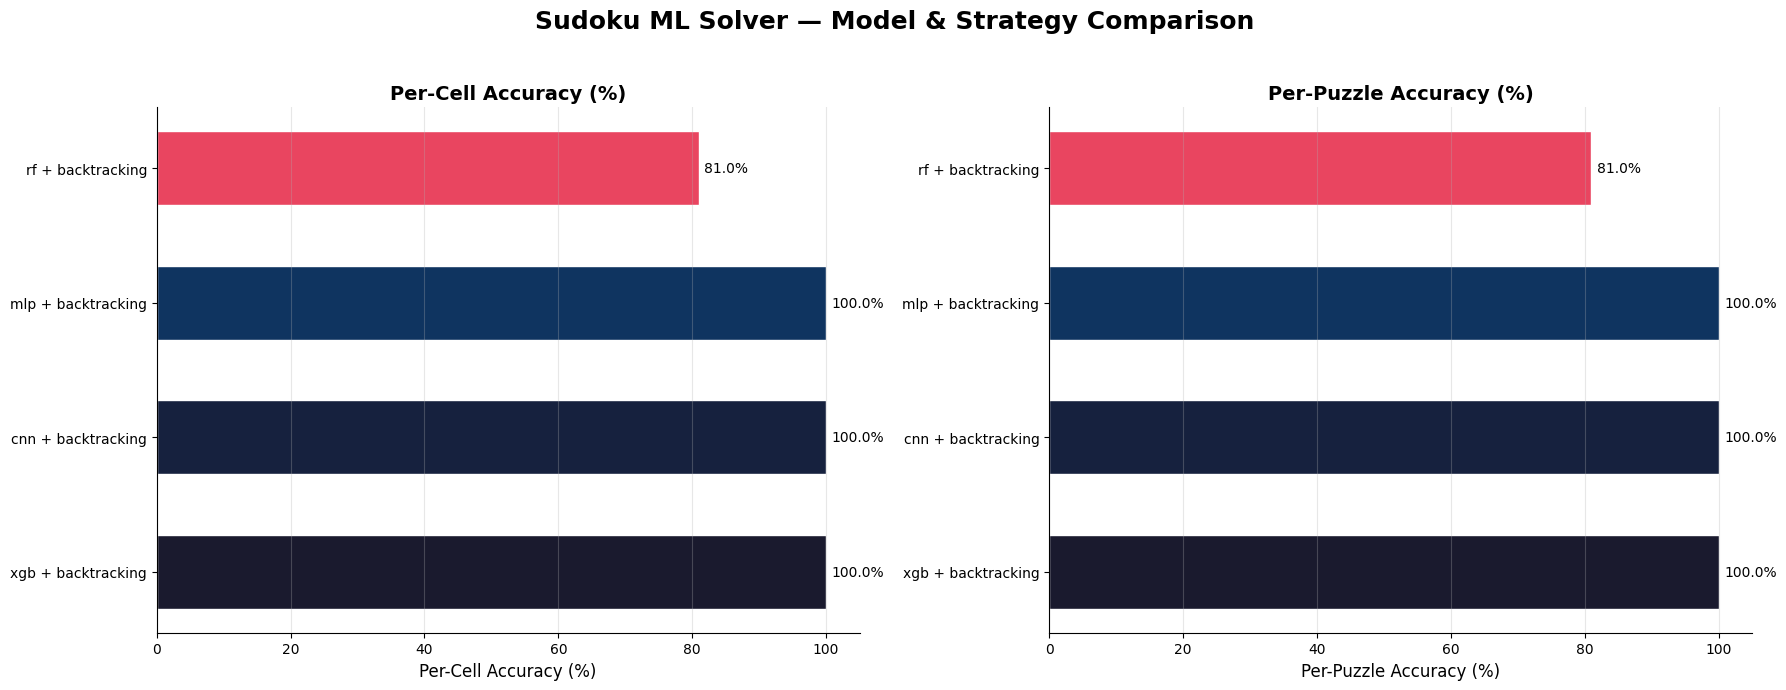

✅ Saved results_all_horizontal.png


In [33]:
# Convert to DataFrame and sort
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='cell_acc', ascending=False)

# Add percentage columns for convenience
results_df['cell_acc_%'] = results_df['cell_acc'] * 100
results_df['puzzle_acc_%'] = results_df['puzzle_acc'] * 100

print(results_df[['label','cell_acc','puzzle_acc']].to_string(index=False))

# --------------------------------------------------
# Horizontal grouped bar chart (clean, readable)
# --------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Sudoku ML Solver — Model & Strategy Comparison', 
             fontsize=18, fontweight='bold')

# Nice color palette
colors = ['#1a1a2e', '#16213e', '#0f3460', '#e94560',
          '#533483', '#2b9348', '#f4a261', '#2a9d8f']

for ax, metric, title in [
    (axes[0], 'cell_acc_%',   'Per-Cell Accuracy (%)'),
    (axes[1], 'puzzle_acc_%', 'Per-Puzzle Accuracy (%)'),
]:
    bars = ax.barh(
        results_df['label'],
        results_df[metric],
        color=colors[:len(results_df)],
        edgecolor='white',
        height=0.55
    )

    # Labels on bars
    ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)

    # Titles & axes
    ax.set_xlabel(title, fontsize=12)
    ax.set_xlim(0, 105)
    ax.set_title(title, fontsize=14, fontweight='bold')

    # Clean look
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('results_all_horizontal.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Saved results_all_horizontal.png")
